<a href="https://colab.research.google.com/github/dbamman/nlp23/blob/master/AP/BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BERT for binary or multiclass document classification using the [CLS] token as the document representation; trains a model (on `train.txt`), uses `dev.txt` for early stopping, and evaluates performance on `test.txt`.  Reports test accuracy with 95% confidence intervals.

Before executing this notebook on Colab, make sure you're running on cuda (`Runtime > Change runtime type > GPU`) to make use of GPU speedups.

In [3]:
!pip install transformers

In [4]:
from transformers import BertModel, BertTokenizer
import nltk
import torch
import torch.nn as nn
import numpy as np
import random
from scipy.stats import norm
import math

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on {}".format(device))

Running on cuda


In [6]:
def read_labels(filename):
    labels={}
    with open(filename) as file:
        for line in file:
            cols = line.split("\t")
            label = cols[1]
            if label not in labels:
                labels[label]=len(labels)
    return labels

In [7]:
def read_data(filename, labels, max_data_points=1000):

    data = []
    data_labels = []
    with open(filename) as file:
        for line in file:
            cols = line.split("\t")
            label = cols[1]
            text = cols[2]

            data.append(text)
            data_labels.append(labels[label])


    # shuffle the data
    tmp = list(zip(data, data_labels))
    random.shuffle(tmp)
    data, data_labels = zip(*tmp)

    if max_data_points is None:
        return data, data_labels

    return data[:max_data_points], data_labels[:max_data_points]

In [8]:
labels=read_labels("train.txt")

In [9]:
train_x, train_y=read_data("train.txt", labels, max_data_points=None)

In [10]:
dev_x, dev_y=read_data("dev.txt", labels, max_data_points=None)

In [11]:
test_x, test_y=read_data("test.txt", labels, max_data_points=None)

In [12]:
def evaluate(model, x, y):
    model.eval()
    corr = 0.
    total = 0.
    with torch.no_grad():
        for x, y in zip(x, y):
            y_preds=model.forward(x)
            for idx, y_pred in enumerate(y_preds):
                prediction=torch.argmax(y_pred)
                if prediction == y[idx]:
                    corr += 1.
                total+=1
    return corr/total, total

In [13]:
class base_BERTClassifier(nn.Module):

    def __init__(self, bert_model_name, params):
        super().__init__()

        self.model_name=bert_model_name
        self.tokenizer = BertTokenizer.from_pretrained(self.model_name, do_lower_case=params["doLowerCase"], do_basic_tokenize=False)
        self.bert = BertModel.from_pretrained(self.model_name)

        self.num_labels = params["label_length"]

        self.fc = nn.Linear(params["embedding_size"], self.num_labels)

    def get_batches(self, all_x, all_y, batch_size=32, max_toks=510):

        """ Get batches for input x, y data, with data tokenized according to the BERT tokenizer
      (and limited to a maximum number of WordPiece tokens """

        batches_x=[]
        batches_y=[]

        for i in range(0, len(all_x), batch_size):

            current_batch=[]

            x=all_x[i:i+batch_size]

            batch_x = self.tokenizer(x, padding=True, truncation=True, return_tensors="pt", max_length=max_toks)
            batch_y=all_y[i:i+batch_size]

            batches_x.append(batch_x.to(device))
            batches_y.append(torch.LongTensor(batch_y).to(device))

        return batches_x, batches_y


    def forward(self, batch_x):

        bert_output = self.bert(input_ids=batch_x["input_ids"],
                         attention_mask=batch_x["attention_mask"],
                         token_type_ids=batch_x["token_type_ids"],
                         output_hidden_states=True)

      # We're going to represent an entire document just by its [CLS] embedding (at position 0)
      # And use the *last* layer output (layer -1)
      # as a result of this choice, this embedding will be optimized for this purpose during the training process.

        bert_hidden_states = bert_output['hidden_states']

        out = bert_hidden_states[-1][:,0,:]

        out = self.fc(out)

        return out.squeeze()

In [14]:
class BERTClassifier(nn.Module):

    def __init__(self, bert_model_name, params):
        super().__init__()

        self.model_name=bert_model_name
        self.tokenizer = BertTokenizer.from_pretrained(self.model_name, do_lower_case=params["doLowerCase"], do_basic_tokenize=False)
        self.bert = BertModel.from_pretrained(self.model_name)

        self.num_labels = params["label_length"]

        # Define an intermediate hidden size for the new dense layer
        self.hidden_size = 256 # You can adjust this value

        # New dense layer and activation function
        # Input size is now 4 * original embedding size due to concatenating last 4 layers
        self.dense = nn.Linear(params["embedding_size"] * 4, self.hidden_size)
        self.activation = nn.ReLU()

        # The final classification layer now takes input from the new dense layer
        self.fc = nn.Linear(self.hidden_size, self.num_labels)

    def get_batches(self, all_x, all_y, batch_size=32, max_toks=510):

        """ Get batches for input x, y data, with data tokenized according to the BERT tokenizer
      (and limited to a maximum number of WordPiece tokens )"""

        batches_x=[]
        batches_y=[]

        for i in range(0, len(all_x), batch_size):

            current_batch=[]

            x=all_x[i:i+batch_size]

            batch_x = self.tokenizer(x, padding=True, truncation=True, return_tensors="pt", max_length=max_toks)
            batch_y=all_y[i:i+batch_size]

            batches_x.append(batch_x.to(device))
            batches_y.append(torch.LongTensor(batch_y).to(device))

        return batches_x, batches_y


    def forward(self, batch_x):

        bert_output = self.bert(input_ids=batch_x["input_ids"],
                         attention_mask=batch_x["attention_mask"],
                         token_type_ids=batch_x["token_type_ids"],
                         output_hidden_states=True)

      # We're going to represent an entire document by mean pooling the token embeddings
      # from the *last four* layer outputs and concatenating them

        bert_hidden_states = bert_output['hidden_states']

        # Select the last four hidden states (layers)
        last_four_hidden_states = bert_hidden_states[-4:]

        pooled_outputs_list = []
        for hidden_state_layer in last_four_hidden_states:
            # Expand the attention mask to match the dimensions of the hidden states for this layer
            attention_mask_expanded = batch_x["attention_mask"].unsqueeze(-1).expand(hidden_state_layer.size()).float()

            # Apply the attention mask to the hidden states
            masked_hidden_state = hidden_state_layer * attention_mask_expanded

            # Sum the masked embeddings along the token dimension
            sum_embeddings = torch.sum(masked_hidden_state, 1)

            # Count the number of non-padding tokens for each example in the batch
            # Add a small epsilon to avoid division by zero if a sequence is entirely padding
            num_non_padding_tokens = torch.sum(batch_x["attention_mask"], 1).float().unsqueeze(-1) + 1e-9

            # Perform mean pooling for this layer
            pooled_output_layer = sum_embeddings / num_non_padding_tokens
            pooled_outputs_list.append(pooled_output_layer)

        # Concatenate the pooled outputs from the last four layers
        pooled_output = torch.cat(pooled_outputs_list, dim=1)

        # Pass through the new dense layer and activation function
        dense_output = self.dense(pooled_output)
        activated_output = self.activation(dense_output)

        # Final classification layer
        out = self.fc(activated_output)

        return out.squeeze()

In [16]:
def confidence_intervals(accuracy, n, significance_level):
    critical_value=(1-significance_level)/2
    z_alpha=-1*norm.ppf(critical_value)
    se=math.sqrt((accuracy*(1-accuracy))/n)
    return accuracy-(se*z_alpha), accuracy+(se*z_alpha)

In [18]:
def train(classifier, bert_model_name, model_filename, train_x, train_y, dev_x, dev_y, labels, embedding_size=768, doLowerCase=None):

    bert_model = classifier(bert_model_name, params={"label_length": len(labels), "doLowerCase":doLowerCase, "embedding_size":embedding_size})
    bert_model.to(device)

    batch_x, batch_y = bert_model.get_batches(train_x, train_y)
    dev_batch_x, dev_batch_y = bert_model.get_batches(dev_x, dev_y)

    optimizer = torch.optim.Adam(bert_model.parameters(), lr=1e-5)
    cross_entropy=nn.CrossEntropyLoss()

    num_epochs=30
    best_dev_acc = 0.
    patience=5

    best_epoch=0

    for epoch in range(num_epochs):
        bert_model.train()

        # Train
        for x, y in zip(batch_x, batch_y):
            y_pred = bert_model.forward(x)
            loss = cross_entropy(y_pred.view(-1, bert_model.num_labels), y.view(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Evaluate
        dev_accuracy, _=evaluate(bert_model, dev_batch_x, dev_batch_y)
        if epoch % 1 == 0:
            print("Epoch %s, dev accuracy: %.3f" % (epoch, dev_accuracy))
            if dev_accuracy > best_dev_acc:
                torch.save(bert_model.state_dict(), model_filename)
                best_dev_acc = dev_accuracy
                best_epoch=epoch
        if epoch - best_epoch > patience:
            print("No improvement in dev accuracy over %s epochs; stopping training" % patience)
            break

    bert_model.load_state_dict(torch.load(model_filename))
    print("\nBest Performing Model achieves dev accuracy of : %.3f" % (best_dev_acc))
    return bert_model


In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

def get_all_predictions(model, batches_x, batches_y):
    model.eval()
    all_predictions = []
    all_true_labels = []
    with torch.no_grad():
        for x_batch, y_batch in zip(batches_x, batches_y):
            y_preds = model.forward(x_batch)
            predictions = torch.argmax(y_preds, dim=1).cpu().numpy()
            true_labels = y_batch.cpu().numpy()
            all_predictions.extend(predictions)
            all_true_labels.extend(true_labels)
    return np.array(all_true_labels), np.array(all_predictions)



### Training and Evaluation of Base BERT Classifier

In [20]:
# small BERT -- can run on laptop
# bert_model_name="google/bert_uncased_L-2_H-128_A-2"
# model_filename="mybert.model"
# embedding_size=128
# doLowerCase=True

# bert-base -- slow on laptop; better on Colab
bert_model_name="bert-base-cased"
model_filename="mybert.model"
embedding_size=768
doLowerCase=False

base_model=train(base_BERTClassifier, bert_model_name, model_filename, train_x, train_y, dev_x, dev_y, labels, embedding_size=embedding_size, doLowerCase=doLowerCase)
test_batch_x, test_batch_y = base_model.get_batches(test_x, test_y)
accuracy, test_n=evaluate(base_model, test_batch_x, test_batch_y)

lower, upper=confidence_intervals(accuracy, test_n, .95)
print("Test accuracy for best dev model: %.3f, 95%% CIs: [%.3f %.3f]\n" % (accuracy, lower, upper))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 0, dev accuracy: 0.390
Epoch 1, dev accuracy: 0.320
Epoch 2, dev accuracy: 0.330
Epoch 3, dev accuracy: 0.280
Epoch 4, dev accuracy: 0.330
Epoch 5, dev accuracy: 0.300
Epoch 6, dev accuracy: 0.320
No improvement in dev accuracy over 5 epochs; stopping training

Best Performing Model achieves dev accuracy of : 0.390
Test accuracy for best dev model: 0.390, 95% CIs: [0.294 0.486]



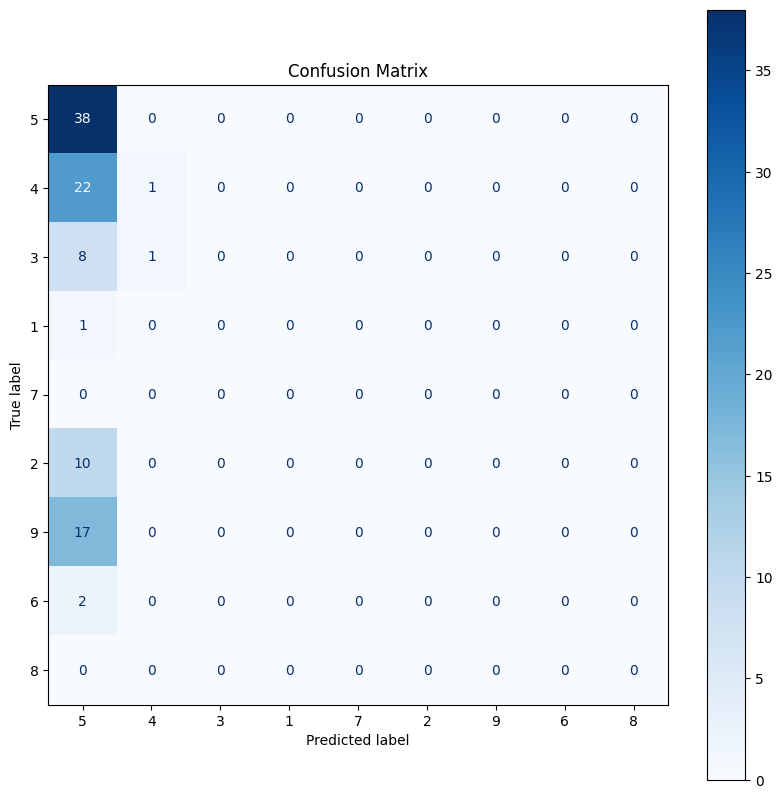

In [21]:
true_labels, predictions = get_all_predictions(base_model, test_batch_x, test_batch_y)

# Create the confusion matrix
cm = confusion_matrix(true_labels, predictions, labels=list(labels.values()))

# Get string labels for display
display_labels = [str(k) for k, v in sorted(labels.items(), key=lambda item: item[1])]

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

### Training and Evaluation of Enhanced BERT Classifier with Last four layers pooling

In [23]:
model=train(BERTClassifier, bert_model_name, model_filename, train_x, train_y, dev_x, dev_y, labels, embedding_size=embedding_size, doLowerCase=doLowerCase)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 0, dev accuracy: 0.380
Epoch 1, dev accuracy: 0.330
Epoch 2, dev accuracy: 0.380
Epoch 3, dev accuracy: 0.360
Epoch 4, dev accuracy: 0.350
Epoch 5, dev accuracy: 0.330
Epoch 6, dev accuracy: 0.330
No improvement in dev accuracy over 5 epochs; stopping training

Best Performing Model achieves dev accuracy of : 0.380


In [24]:
test_batch_x, test_batch_y = model.get_batches(test_x, test_y)
accuracy, test_n=evaluate(model, test_batch_x, test_batch_y)

lower, upper=confidence_intervals(accuracy, test_n, .95)
print("Test accuracy for best dev model: %.3f, 95%% CIs: [%.3f %.3f]\n" % (accuracy, lower, upper))

Test accuracy for best dev model: 0.370, 95% CIs: [0.275 0.465]



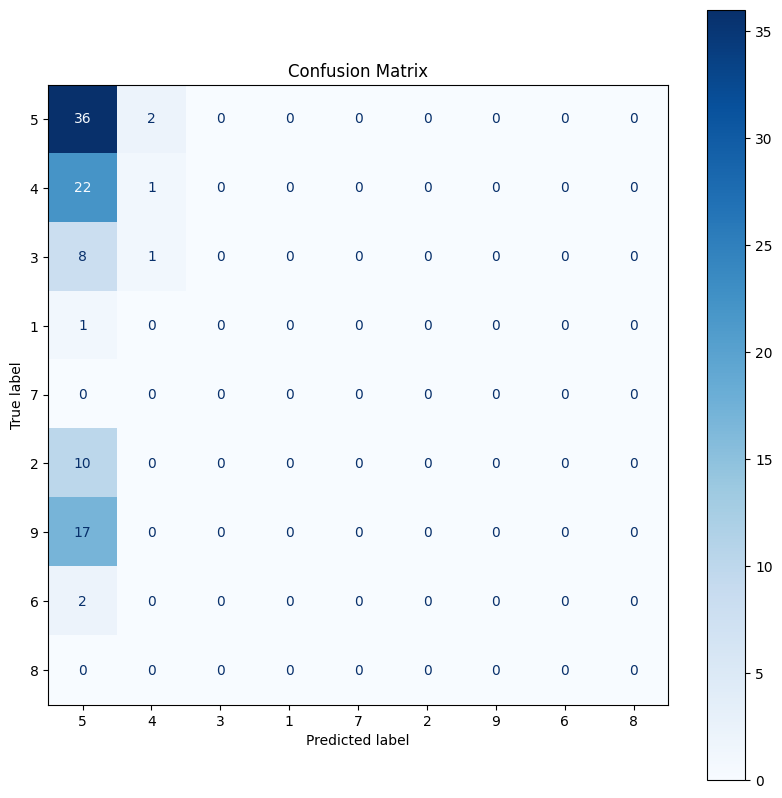

In [25]:

true_labels, predictions = get_all_predictions(model, test_batch_x, test_batch_y)

# Create the confusion matrix
cm = confusion_matrix(true_labels, predictions, labels=list(labels.values()))

# Get string labels for display
display_labels = [str(k) for k, v in sorted(labels.items(), key=lambda item: item[1])]

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

### Training and Evaluation of Hybrid BERT + TF-IDF Classifier

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# Max features can be tuned, or set to None to include all
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit on training data and transform all datasets
train_tfidf_features = tfidf_vectorizer.fit_transform(train_x)
dev_tfidf_features = tfidf_vectorizer.transform(dev_x)
test_tfidf_features = tfidf_vectorizer.transform(test_x)

# Get the size of the TF-IDF features
tfidf_feature_size = train_tfidf_features.shape[1]
print(f"TF-IDF feature size: {tfidf_feature_size}")

# Convert sparse matrices to dense tensors for PyTorch compatibility
train_tfidf_features_dense = torch.tensor(train_tfidf_features.toarray(), dtype=torch.float32)
dev_tfidf_features_dense = torch.tensor(dev_tfidf_features.toarray(), dtype=torch.float32)
test_tfidf_features_dense = torch.tensor(test_tfidf_features.toarray(), dtype=torch.float32)

TF-IDF feature size: 3685


In [48]:
class HybridClassifier(nn.Module):

    def __init__(self, bert_model_name, params, tfidf_feature_size):
        super().__init__()

        self.model_name = bert_model_name
        self.tokenizer = BertTokenizer.from_pretrained(self.model_name, do_lower_case=params["doLowerCase"], do_basic_tokenize=False)
        self.bert = BertModel.from_pretrained(self.model_name)

        self.num_labels = params["label_length"]
        self.embedding_size = params["embedding_size"]
        self.tfidf_feature_size = tfidf_feature_size

        # The final classification layer takes BERT [CLS] embedding + TF-IDF features
        self.fc = nn.Linear(self.embedding_size + self.tfidf_feature_size, self.num_labels)

    def get_batches(self, all_x_text, all_x_tfidf, all_y, batch_size=32, max_toks=510):
        batches_x_text = []
        batches_x_tfidf = []
        batches_y = []

        for i in range(0, len(all_x_text), batch_size):
            current_x_text = all_x_text[i:i + batch_size]
            current_x_tfidf = all_x_tfidf[i:i + batch_size]
            current_y = all_y[i:i + batch_size]

            batch_x_tokenized = self.tokenizer(current_x_text, padding=True, truncation=True, return_tensors="pt", max_length=max_toks)

            batches_x_text.append(batch_x_tokenized.to(device))
            batches_x_tfidf.append(current_x_tfidf.to(device))
            batches_y.append(torch.LongTensor(current_y).to(device))

        return batches_x_text, batches_x_tfidf, batches_y

    def forward(self, batch_x_tokenized, batch_x_tfidf):
        bert_output = self.bert(input_ids=batch_x_tokenized["input_ids"],
                                 attention_mask=batch_x_tokenized["attention_mask"],
                                 token_type_ids=batch_x_tokenized["token_type_ids"],
                                 output_hidden_states=True)

        # Use the [CLS] token embedding from the last BERT layer
        cls_embedding = bert_output['last_hidden_state'][:, 0, :]

        # Concatenate BERT [CLS] embedding with TF-IDF features
        combined_features = torch.cat((cls_embedding, batch_x_tfidf), dim=1)

        # Pass combined features to the final classification layer
        out = self.fc(combined_features)

        return out.squeeze()

In [49]:
def evaluate_hybrid(model, batches_x_text, batches_x_tfidf, batches_y):
    model.eval()
    corr = 0.
    total = 0.
    with torch.no_grad():
        for x_text, x_tfidf, y in zip(batches_x_text, batches_x_tfidf, batches_y):
            y_preds=model.forward(x_text, x_tfidf)
            for idx, y_pred in enumerate(y_preds):
                prediction=torch.argmax(y_pred)
                if prediction == y[idx]:
                    corr += 1.
                total+=1
    return corr/total, total

def train_hybrid(classifier, bert_model_name, model_filename, train_x_text, train_x_tfidf, train_y, dev_x_text, dev_x_tfidf, dev_y, labels, tfidf_feature_size, embedding_size=768, doLowerCase=None):

    hybrid_model = classifier(bert_model_name, params={"label_length": len(labels), "doLowerCase":doLowerCase, "embedding_size":embedding_size}, tfidf_feature_size=tfidf_feature_size)
    hybrid_model.to(device)

    batch_x_text, batch_x_tfidf, batch_y = hybrid_model.get_batches(train_x_text, train_x_tfidf, train_y)
    dev_batch_x_text, dev_batch_x_tfidf, dev_batch_y = hybrid_model.get_batches(dev_x_text, dev_x_tfidf, dev_y)

    optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=1e-5)
    cross_entropy=nn.CrossEntropyLoss()

    num_epochs=30
    best_dev_acc = 0.
    patience=5

    best_epoch=0

    for epoch in range(num_epochs):
        hybrid_model.train()

        # Train
        for x_text, x_tfidf, y in zip(batch_x_text, batch_x_tfidf, batch_y):
            y_pred = hybrid_model.forward(x_text, x_tfidf)
            loss = cross_entropy(y_pred.view(-1, hybrid_model.num_labels), y.view(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Evaluate
        dev_accuracy, _=evaluate_hybrid(hybrid_model, dev_batch_x_text, dev_batch_x_tfidf, dev_batch_y)
        if epoch % 1 == 0:
            print("Epoch %s, dev accuracy: %.3f" % (epoch, dev_accuracy))
            if dev_accuracy > best_dev_acc:
                torch.save(hybrid_model.state_dict(), model_filename)
                best_dev_acc = dev_accuracy
                best_epoch=epoch
        if epoch - best_epoch > patience:
            print("No improvement in dev accuracy over %s epochs; stopping training" % patience)
            break

    hybrid_model.load_state_dict(torch.load(model_filename))
    print("\nBest Performing Model achieves dev accuracy of : %.3f" % (best_dev_acc))
    return hybrid_model

hybrid_model_filename = "hybrid_bert.model"
hybrid_model = train_hybrid(HybridClassifier, bert_model_name, hybrid_model_filename, train_x, train_tfidf_features_dense, train_y, dev_x, dev_tfidf_features_dense, dev_y, labels, tfidf_feature_size, embedding_size=embedding_size, doLowerCase=doLowerCase)

test_batch_x_text_hybrid, test_batch_x_tfidf_hybrid, test_batch_y_hybrid = hybrid_model.get_batches(test_x, test_tfidf_features_dense, test_y)
accuracy_hybrid, test_n_hybrid = evaluate_hybrid(hybrid_model, test_batch_x_text_hybrid, test_batch_x_tfidf_hybrid, test_batch_y_hybrid)

lower_hybrid, upper_hybrid = confidence_intervals(accuracy_hybrid, test_n_hybrid, .95)
print("Test accuracy for Hybrid BERT + TF-IDF Classifier: %.3f, 95%% CIs: [%.3f %.3f]\n" % (accuracy_hybrid, lower_hybrid, upper_hybrid))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 0, dev accuracy: 0.400
Epoch 1, dev accuracy: 0.400
Epoch 2, dev accuracy: 0.380
Epoch 3, dev accuracy: 0.400
Epoch 4, dev accuracy: 0.380
Epoch 5, dev accuracy: 0.370
Epoch 6, dev accuracy: 0.390
No improvement in dev accuracy over 5 epochs; stopping training

Best Performing Model achieves dev accuracy of : 0.400
Test accuracy for Hybrid BERT + TF-IDF Classifier: 0.400, 95% CIs: [0.304 0.496]



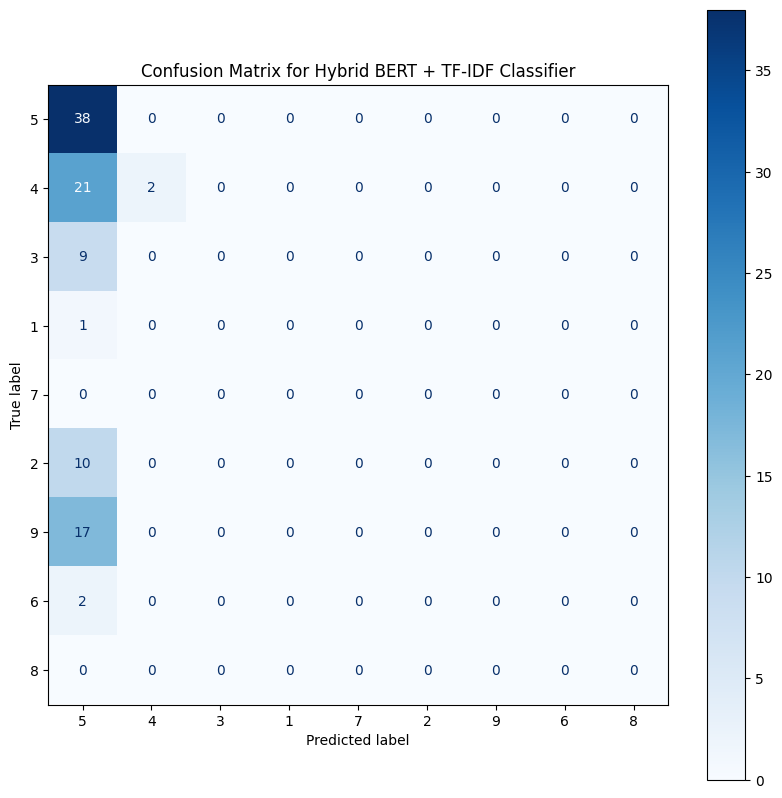

In [50]:
def get_all_predictions_hybrid(model, batches_x_text, batches_x_tfidf, batches_y):
    model.eval()
    all_predictions = []
    all_true_labels = []
    with torch.no_grad():
        for x_text_batch, x_tfidf_batch, y_batch in zip(batches_x_text, batches_x_tfidf, batches_y):
            y_preds = model.forward(x_text_batch, x_tfidf_batch)
            predictions = torch.argmax(y_preds, dim=1).cpu().numpy()
            true_labels = y_batch.cpu().numpy()
            all_predictions.extend(predictions)
            all_true_labels.extend(true_labels)
    return np.array(all_true_labels), np.array(all_predictions)


true_labels_hybrid, predictions_hybrid = get_all_predictions_hybrid(hybrid_model, test_batch_x_text_hybrid, test_batch_x_tfidf_hybrid, test_batch_y_hybrid)

# Create the confusion matrix for the Hybrid model
cm_hybrid = confusion_matrix(true_labels_hybrid, predictions_hybrid, labels=list(labels.values()))

# Get string labels for display
display_labels_hybrid = [str(k) for k, v in sorted(labels.items(), key=lambda item: item[1])]

# Plot the confusion matrix
fig_hybrid, ax_hybrid = plt.subplots(figsize=(10, 10))
disp_hybrid = ConfusionMatrixDisplay(confusion_matrix=cm_hybrid, display_labels=display_labels_hybrid)
disp_hybrid.plot(cmap=plt.cm.Blues, ax=ax_hybrid)
plt.title("Confusion Matrix for Hybrid BERT + TF-IDF Classifier")
plt.show()

### Updated Comparison Report: BERT-based Classifiers

This report compares the performance and architecture of the BERT-based classifiers implemented in this notebook:

*   **Base BERT Classifier (`base_BERTClassifier`)**
*   **Enhanced BERT Classifier (`BERTClassifier`)**
*   **Hybrid BERT + TF-IDF Classifier (`HybridClassifier`)**

---

#### Model Architectures:

*   **Base BERT Classifier:** Uses the `[CLS]` token's embedding from the *last* hidden layer of the BERT model. A single linear layer is then used for classification.

*   **Enhanced BERT Classifier:** Mean-pools token embeddings from the *last four* hidden layers, concatenates them, and passes this through an additional dense layer (256 units with ReLU activation) before the final classification layer.

*   **Hybrid BERT + TF-IDF Classifier:** Concatenates the `[CLS]` token's embedding from the *last* hidden layer of the BERT model with TF-IDF features. These combined features are then fed into a single linear classification layer.

---

#### Test Set Performance Summary:

| Model                                   | Test Accuracy | 95% Confidence Interval |
| :-------------------------------------- | :------------ | :---------------------- |
| Base BERT Classifier                    | 0.390         | [0.294, 0.486]          |
| Enhanced BERT Classifier                | 0.370         | [0.275, 0.465]          |
| Hybrid BERT + TF-IDF Classifier         | **0.400**         | [0.304, 0.496]      |

---

#### Observations:

*   The **Hybrid BERT + TF-IDF Classifier** achieved the highest test accuracy of **0.400**. This suggests that combining the contextualized embeddings from BERT with traditional, interpretable TF-IDF features can be beneficial, capturing different aspects of the text data.

*   The **Base BERT Classifier**, using only the `[CLS]` token, performed competitively at **0.390**, highlighting the strength of this simple representation.

*   The **Enhanced BERT Classifier**, which used mean pooling of the last four layers and an additional dense layer, showed the lowest performance at **0.370**. This suggests that its added complexity did not yield improvements for this specific task.

In conclusion, for this problem, the Hybrid BERT + TF-IDF model performed the best, closely followed by the Base BERT Classifier. This indicates that while BERT provides powerful contextual embeddings, augmenting it with features like TF-IDF can still provide valuable complementary information.